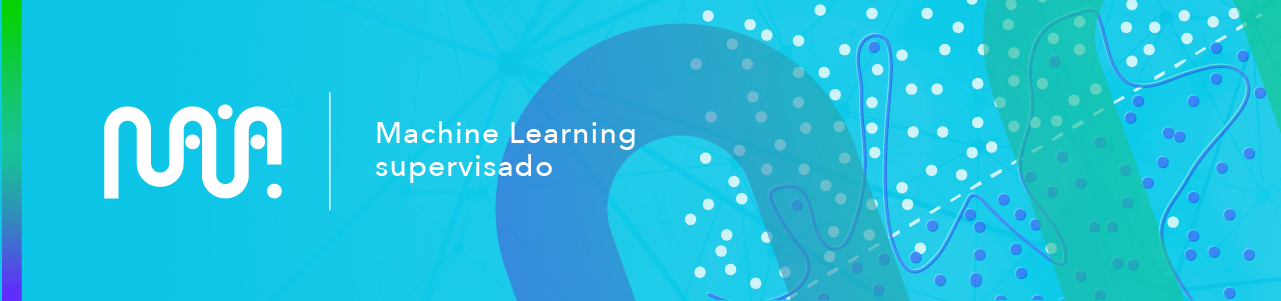
# Taller: Problema de regresión con SVR

***MLS. Machine learning supervisado***
<br>***Semana 5, Taller:*** *SVR*
<br> **Profesor:** *Fernando Lozano* - **Autor Notebook:** *Mónica Gantiva*



## Introducción
### Descripción
Este *jupyter notebook* contiene el material necesario para el desarrollo del Taller calificable de la Semana 5 del curso *MLS: Machine learning supervisado*. En esta tarea se presentará un problema de regresión que será resuelto aplicando SVR. Usted deberá modificar hiperparámetros del modelo para mejorar su desempeño y analizar los resultados.

#### Objetivos de Aprendizaje
Aplicar modelos basados en kernel para resolver problemas de regresión. 

### Teoría

###  Support Vector Machine (SVM):
En terminos generales una máquina de soporte vectorial (o SVM por sus siglas en inglés) es un modelo de clasificación que busca encontrar el híperplano que separe de mejor manera los datos de dos o varias clases. Esta tarea se puede plantear como un simple problema de optimización con restricciones. En últimas lo que se desea es encontrar la separación óptima de los datos.

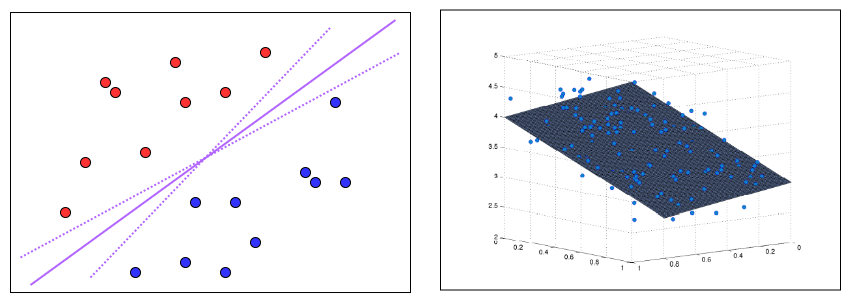

Un Support Vector Machine (SVM) es un algoritmo de aprendizaje supervisado que puede utilizarse tanto para clasificación como para regresión. Cuando se utiliza para regresión, se denomina Support Vector Regression (SVR). Ambos SVM y SVR comparten el mismo principio fundamental, que es encontrar un hiperplano en un espacio de alta dimensión que tenga la máxima distancia a los puntos de datos de las clases o, en el caso de SVR, que tenga la máxima distancia a los puntos de datos en la regresión.

### Support Vector Regression (SVR):

**Objetivo de la Regresión:**

A diferencia de la clasificación, donde el objetivo es encontrar un hiperplano que separe las clases, en la regresión (SVR), el objetivo es encontrar un hiperplano que maximice la cantidad de puntos de datos (muestras) que están dentro de un margen (llamado "margen insensitivo") alrededor de la línea de regresión.

**Margen Insensitivo:**
En SVR, se permite que algunos puntos estén dentro del margen insensitivo o incluso en el lado incorrecto del hiperplano, pero se penalizan según cuán lejos estén de la predicción.

**Kernel Trick:**
Similar a SVM, SVR puede hacer uso del "kernel trick". El kernel transforma los datos de entrada a un espacio de mayor dimensión, permitiendo a SVR manejar relaciones no lineales entre características.

**Parámetros:**
Algunos de los parámetros clave de SVR incluyen el tipo de kernel (lineal, RBF, polinómico, etc.), el parámetro de regularización C, y otros específicos del kernel (como el coeficiente gamma para el kernel RBF).

### Metodología
En este taller se abordará un poblema aplicado de regresión para el cual usted deberá tomar el modelo de SVR y mejorar su desempeño. Para ello emplee las celdas que tienen la siguiente notación.


In [1]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

Así mismo, usted deberá análizar los resultados obtenidos para cada modelo. Para ello, responda las preguntas que se presentarán durante el taller. Dispondra de celdas con la siguiente notación para escribir su análisis:


***Respuesta:***

### Problema aplicado: Predicción del precios de casas en Boston

#### Inicialización

In [2]:
import pandas as pd
import numpy as np 
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

#### Cargamos los datos

In [4]:
boston = load_boston()

# DataFrame de Características
data = pd.DataFrame(data=boston['data'], columns=boston['feature_names'])
data.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


Esta base de datos proviene del conjunto de datos Boston Housing Prices y contiene información de precios de viviendas en Boston 

### Separación de datos

In [5]:
X = boston.data  # características
y = boston.target  # etiquetas


# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Ejemplo: SVR
Ahora se muestra un ejemplo de cómo aplicar un SVR para realizar la predicción del precio de las casas en Boston. Observe que se crea el modelo, se hace el entrenamiento y se evalúa el desempeño del modelo para el conjunto de entrenamiento y prueba. Por último, se obtiene el desempeño del modelo. Se muestra el error de predicción y la gráfica de dispersión de valores reales frente a los valores predichos. 

Mean Squared Error: 44.33500513460085


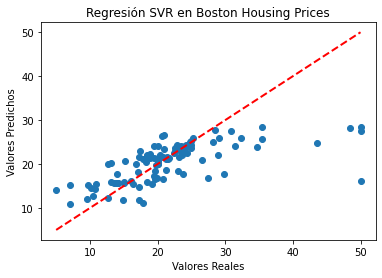

In [6]:
# Creación del modelo SVR
svr = SVR(kernel='rbf', C=10.0, epsilon=0.2)

#Entrenamiento del modelo
svr.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = svr.predict(X_test)

# Evaluar el rendimiento del modelo
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Graficar resultados
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión SVR en Boston Housing Prices')
plt.show()


Tomando como guía el ejemplo anterior, modifique los hiperparámetros del modelo con el propósito de mejorar su desempeño. Recuerde que puede modificar los siguientes parámetros:

**C (parámetro de regularización):** Controla el equilibrio entre un límite suave y un límite ajustado. Valores más altos de C conducen a límites más ajustados.

**epsilon (margen insensitivo):** Especifica la cantidad de error tolerado en la predicción. Valores más altos permiten un mayor error en las predicciones.

**kernel (núcleo):** Puedes experimentar con diferentes funciones de kernel, como 'linear', 'rbf' (radial basis function), 'poly' (polinómico), etc.

Varie estos hiperparámetros de la siguiente manera:

**C** de 0.1 a 10

**epsilon** de 0.1 a 0.5

**kernel**, aplique los kernal:linear, rbf o poly

Pruebe diferentes combinaciones de hiperparámetros y muestre el desempeño del modelo para al menos 4 casos (el error y la gráfica de dispersión de valores reales frente a los valores predichos). *Puede utilizar GridSearchCV*

Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Resultados obtenidos (CV MSE, MSE test, R2 test) ===



,param_kernel,param_C,param_epsilon,MSE_VC,MSE_test,R2_test
0,linear,0.1,0.1,26.832353,24.636592,0.664049
1,rbf,0.1,0.1,79.234463,61.426150,0.162376
2,poly,0.1,0.1,75.521761,58.792436,0.198290
3,linear,0.1,0.3,26.906235,24.327224,0.668267
4,rbf,0.1,0.3,79.050051,61.304347,0.164037
5,poly,0.1,0.3,75.664093,58.780242,0.198456
6,linear,0.1,0.5,27.042565,24.247125,0.669359
7,rbf,0.1,0.5,79.263347,61.053274,0.167460
8,poly,0.1,0.5,75.411484,58.869391,0.197240
9,linear,1,0.1,26.803620,29.435909,0.598604



=== Desempeño de los 4 mejores (ordenados por MSE en test) ===



,param_kernel,param_C,param_epsilon,MSE_VC,MSE_test,R2_test
6,linear,0.1,0.5,27.042565,24.247125,0.669359
3,linear,0.1,0.3,26.906235,24.327224,0.668267
0,linear,0.1,0.1,26.832353,24.636592,0.664049
15,linear,1,0.5,26.722655,28.740438,0.608087


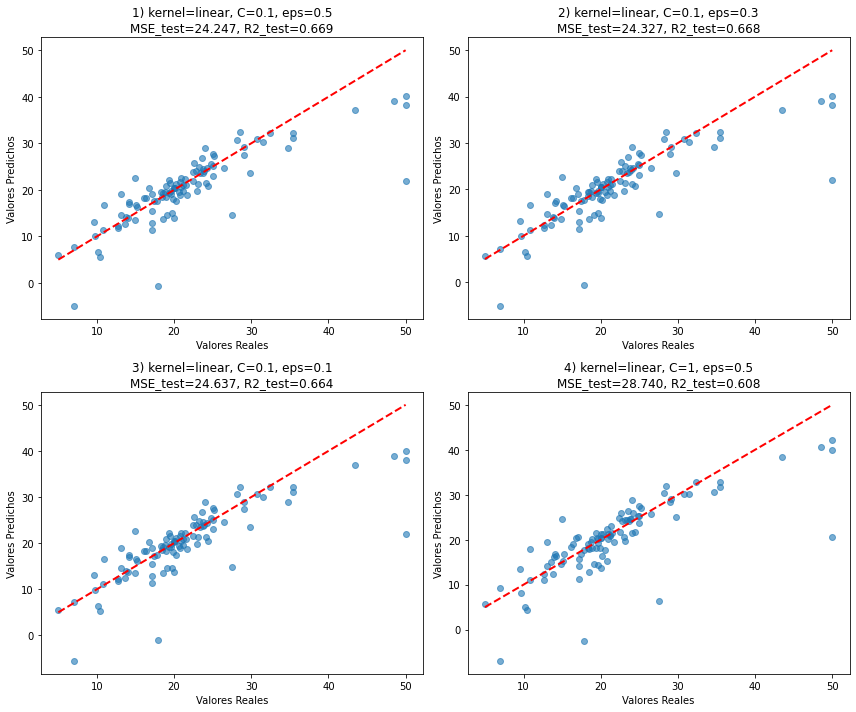

In [9]:
# =====================================================
# COMPLETAR ===========================================
# you code here
# =====================================
# Definimos los rangos de hiperparámetros
# Se eligen solo algunos valores del rango dado para no tardar tanto en tiempos de ejecucion:
param_grid = {
    "C": [0.1, 1, 5, 10],              # C entre 0.1 y 10 (ejemplos representativos)
    "epsilon": [0.1, 0.3, 0.5],        # epsilon entre 0.1 y 0.5
    "kernel": ['linear', 'rbf', 'poly']
}

# Implementamos GridSearchCV sobre MSE (CV)

svr = SVR()
grid_search = GridSearchCV(
    estimator = svr,
    param_grid = param_grid,
    scoring = "neg_mean_squared_error",  # optimizamos MSE en CV
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

# Ejecutamos la búsqueda
grid_search.fit(X_train, y_train)

# Convertimos los resultados y guardarlos en MSE (CV)
resultados = pd.DataFrame(grid_search.cv_results_)
resultados["MSE_VC"] = - resultados["mean_test_score"]   # convertir negativo a positivo

# Calculamos MSE y R2 en el conjunto de test para cada combinación
# (reentrenando cada combinación sobre todo X_train)
mse_test_list = []
r2_test_list = []

for idx, row in resultados.iterrows():
    kernel = row["param_kernel"]
    C = row["param_C"]
    eps = row["param_epsilon"]
    
    model = SVR(kernel=kernel, C=C, epsilon=eps)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    
    mse_test_list.append(mean_squared_error(y_test, y_pred_test))
    r2_test_list.append(r2_score(y_test, y_pred_test))

resultados["MSE_test"] = mse_test_list
resultados["R2_test"] = r2_test_list

# Mostrar TODOS los resultados (validación cruzada (CV) + test)
print("\n=== Resultados obtenidos (CV MSE, MSE test, R2 test) ===\n")
display(resultados.loc[:, ["param_kernel", "param_C", "param_epsilon", "MSE_VC", "MSE_test", "R2_test"]])

# Seleccionamos los 4 mejores
mejores = resultados.sort_values(by="MSE_test").head(4)

print("\n=== Desempeño de los 4 mejores (ordenados por MSE en test) ===\n")
display(mejores.loc[:, ["param_kernel", "param_C", "param_epsilon", "MSE_VC", "MSE_test", "R2_test"]])

# Graficamos dispersión valores reales vs predichos para los 4 mejores
plt.figure(figsize=(12, 10))

for i, fila in enumerate(mejores.itertuples()):
    # Reentrenamos el modelo
    model = SVR(kernel=fila.param_kernel, C=fila.param_C, epsilon=fila.param_epsilon)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    plt.subplot(2, 2, i+1)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=2)
    plt.title(f"{i+1}) kernel={fila.param_kernel}, C={fila.param_C}, eps={fila.param_epsilon}\nMSE_test={mse:.3f}, R2_test={r2:.3f}")
    plt.xlabel("Valores Reales")
    plt.ylabel("Valores Predichos")

plt.tight_layout()
plt.show()

# =====================================================

Responda la siguientes preguntas:
1. ¿Cómo afecta la variación de estos hiparámetros en el desempeño del modelo? Justifique su respuesta para el C, los diferentes kernel empleado y epsilon
2. ¿Cuál fué el modelo con mejor desempeño? ¿Cómo se refleja esto en la gráfica de dispersión?

***RESPUESTAS***

1. ¿Cómo afecta la variación de estos hiperparámetros en el desempeño del modelo?


  * **Parámetro C (regularización):**
   
Al aumentar el valor de C, el modelo se vuelve más estricto, intentando ajustarse con mayor precisión a los datos de entrenamiento. Sin embargo, en este caso se observó que **valores bajos de C (0.1)** ofrecieron un mejor desempeño en el conjunto de prueba. Cuando C aumentó a 5 o 10, el error en test creció y el R2 disminuyó, lo cual indica un sobreajuste y una pérdida de capacidad de generalización.

   * **Kernel (función núcleo):**
   
Se evaluaron tres funciones núcleo: lineal, RBF y polinómica. Los resultados muestran que el **kernel lineal superó claramente a los otros**, alcanzando los menores errores (MSE entre 24 y 30) y los mayores coeficientes de determinación (R2 entre 0.60 y 0.67). En contraste, los kernels RBF y polinómico obtuvieron errores mucho mayores (MSE entre 42 y 61, R2 apenas entre 0.16 y 0.42). Esto indica que la relación entre las variables en este conjunto de datos es esencialmente lineal, por lo que introducir transformaciones no lineales no aporta beneficio y empeora el ajuste.

   * **Parámetro epsilon (margen insensible):**
   
El epsilon define el rango de error tolerado sin penalización. Valores pequeños (0.1) hicieron que el modelo tratara de ajustarse más estrictamente, mientras que valores más amplios (0.3 y 0.5) le dieron mayor flexibilidad. El mejor desempeño se alcanzó con **epsilon = 0.5**, lo que sugiere que permitir un cierto margen de error mejora la estabilidad del modelo y reduce el sobreajuste.


2. ¿Cuál fue el modelo con mejor desempeño? ¿Cómo se refleja esto en la gráfica de dispersión?

El mejor modelo encontrado fue el SVR con kernel lineal, C = 0.1 y epsilon = 0.5, el cual alcanzó:

  * **MSE_test = 24.25**
  * **R2_test = 0.669**

En la gráfica de dispersión correspondiente, este modelo muestra que los puntos predichos se alinean de manera más cercana a la diagonal roja (línea de perfecta predicción). Aunque aún existen desviaciones y dispersión en algunos valores extremos, la mayoría de las observaciones siguen de manera bastante fiel la tendencia lineal, lo que confirma que el modelo captura bien la relación subyacente entre las variables.